# Urban Heat Island (UHI) Analysis: Spatial LST Analytics & XGBoost

This project analyzes **Land Surface Temperature (LST)** as a spatial indicator of urban heat patterns associated with the **Urban Heat Island (UHI)** phenomenon.

The notebook is designed as an **analytics-first geospatial machine-learning project**:

1. Understand the data and its spatial structure.
2. Compare LST across 2025 and 2026.
3. Quantify relationships between LST and environmental / built-environment variables.
4. Identify high-LST locations and visualize spatial patterns.
5. Build a spatially validated Random Forest and XGBoost model.
6. Explain model behavior with feature importance and SHAP.
7. Translate the analysis into practical, evidence-based findings.

> **Scope note:** This notebook predicts and analyzes LST. It does **not** calculate a conventional UHI intensity index from urban and rural reference temperatures. Therefore, conclusions are framed as **urban heat / LST patterns**, not as a direct UHI-intensity estimate.

## 1. Project Questions

The analysis is organized around questions that are useful for both urban-heat research and an analytics portfolio:

- How is LST distributed across the study area?
- Did the LST distribution change between 2025 and 2026?
- Which land-use / land-cover (LULC) categories have the highest and lowest average LST?
- Which numeric variables show the strongest relationships with LST?
- Where are the highest-LST observations located spatially?
- How well can LST be predicted when geographically separated areas are held out?
- Which variables contribute most to the XGBoost predictions?
- Are model errors concentrated in particular parts of the study area?

## 2. Imports and Configuration

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPATIAL_BLOCKS = 10
TEST_SIZE = 0.20
N_REPEATS = 10

# Set to False on a machine without CUDA-enabled XGBoost.
USE_GPU = True
XGB_DEVICE = "cuda" if USE_GPU else "cpu"

# Keep SHAP responsive on large datasets.
SHAP_SAMPLE_SIZE = 10_000

In [2]:
# Verify that the configured XGBoost installation can use CUDA.
# This is a tiny synthetic test and does not use the project dataset.

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

gpu_test = XGBRegressor(
    n_estimators=10,
    tree_method="hist",
    device=XGB_DEVICE,
    random_state=RANDOM_STATE,
)

X_gpu_test = pd.DataFrame({
    "x1": np.arange(100, dtype=float),
    "x2": np.random.default_rng(RANDOM_STATE).normal(size=100),
})
y_gpu_test = 2 * X_gpu_test["x1"] + X_gpu_test["x2"]

gpu_test.fit(X_gpu_test, y_gpu_test)

print(f"Configured device: {XGB_DEVICE}")
print("GPU test successful." if USE_GPU else "CPU test successful.")

XGBoost version: 3.0.5
Configured device: cuda
GPU test successful.


## 3. Load and Combine the 2025–2026 Datasets

In [3]:
df_2025 = pd.read_csv("150m2025Dataset.csv")
df_2026 = pd.read_csv("150m2026Dataset.csv")

df_2025["year"] = 2025
df_2026["year"] = 2026

df_raw = pd.concat([df_2025, df_2026], ignore_index=True)

print(f"2025: {df_2025.shape[0]:,} rows × {df_2025.shape[1]:,} columns")
print(f"2026: {df_2026.shape[0]:,} rows × {df_2026.shape[1]:,} columns")
print(f"Combined: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")

2025: 59,631 rows × 26 columns
2026: 59,631 rows × 26 columns
Combined: 119,262 rows × 26 columns


## 4. Geographic Coordinates

In [4]:
def extract_coordinates(geo_string):
    geometry = json.loads(geo_string)
    longitude, latitude = geometry["coordinates"]
    return pd.Series({"longitude": longitude, "latitude": latitude})

coordinates = df_raw[".geo"].apply(extract_coordinates)
df_raw[["longitude", "latitude"]] = coordinates

print(
    f"Longitude range: {df_raw['longitude'].min():.6f} to "
    f"{df_raw['longitude'].max():.6f}"
)
print(
    f"Latitude range: {df_raw['latitude'].min():.6f} to "
    f"{df_raw['latitude'].max():.6f}"
)

Longitude range: 76.979107 to 77.545046
Latitude range: 28.400013 to 28.793475


## 5. Data Quality & Dataset Overview

In [5]:
overview = pd.DataFrame({
    "rows": [len(df_raw)],
    "columns": [df_raw.shape[1]],
    "numeric_columns": [df_raw.select_dtypes(include=np.number).shape[1]],
    "categorical_columns": [df_raw.select_dtypes(exclude=np.number).shape[1]],
    "total_missing_values": [int(df_raw.isna().sum().sum())],
    "duplicate_rows": [int(df_raw.duplicated().sum())],
})

overview.T.rename(columns={0: "value"})

,value
rows,119262
columns,28
numeric_columns,27
categorical_columns,1
total_missing_values,0
duplicate_rows,0


In [6]:
missing = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing["missing_pct"] = 100 * missing["missing_count"] / len(df_raw)

missing = missing[missing["missing_count"] > 0]

if missing.empty:
    print("No missing values found.")
else:
    display(missing.head(20))

No missing values found.


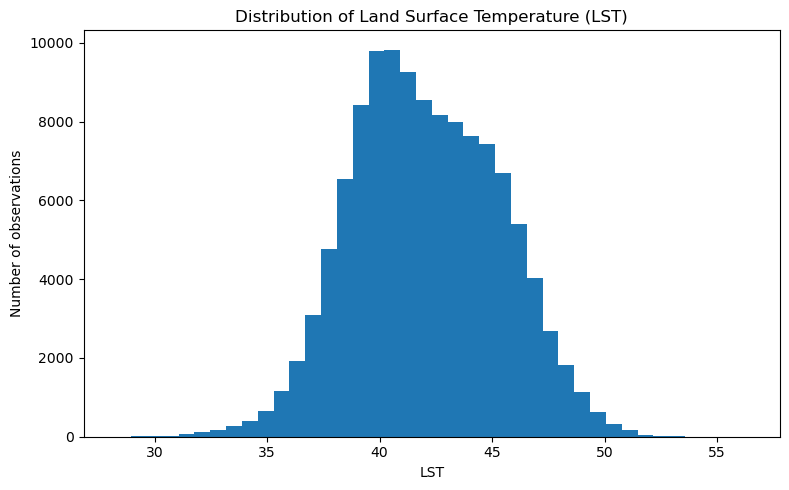

count    119262.000
mean         42.046
std           3.286
min          28.244
25%          39.659
50%          41.867
75%          44.481
max          56.393
Name: LST, dtype: float64


In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df_raw["LST"].dropna(), bins=40)
plt.xlabel("LST")
plt.ylabel("Number of observations")
plt.title("Distribution of Land Surface Temperature (LST)")
plt.tight_layout()
plt.show()

print(df_raw["LST"].describe().round(3))

### LST Outlier Check

In [8]:
q1, q3 = df_raw["LST"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (df_raw["LST"] < lower_bound) | (df_raw["LST"] > upper_bound)

print(f"IQR lower bound: {lower_bound:.3f}")
print(f"IQR upper bound: {upper_bound:.3f}")
print(f"Potential IQR outliers: {outlier_mask.sum():,} ({outlier_mask.mean()*100:.2f}%)")
print("Outliers are retained; this step is descriptive rather than an automatic deletion rule.")

IQR lower bound: 32.424
IQR upper bound: 51.716
Potential IQR outliers: 339 (0.28%)
Outliers are retained; this step is descriptive rather than an automatic deletion rule.


## 6. 2025 vs 2026 LST Comparison

In [9]:
year_summary = (
    df_raw.groupby("year")["LST"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

year_summary

,count,mean,median,std,min,max
year,,,,,,
2025,59631,39.958,39.966,2.298,28.244,49.776
2026,59631,44.133,44.319,2.756,29.606,56.393


In [10]:
year_stats = df_raw.groupby("year")["LST"].mean()

if {2025, 2026}.issubset(year_stats.index):
    mean_change = year_stats.loc[2026] - year_stats.loc[2025]
    pct_change = 100 * mean_change / year_stats.loc[2025]
    print(f"Mean LST change (2026 - 2025): {mean_change:.3f}")
    print(f"Percentage change in mean LST: {pct_change:.2f}%")
else:
    print("Both 2025 and 2026 are required for year-over-year comparison.")

Mean LST change (2026 - 2025): 4.175
Percentage change in mean LST: 10.45%


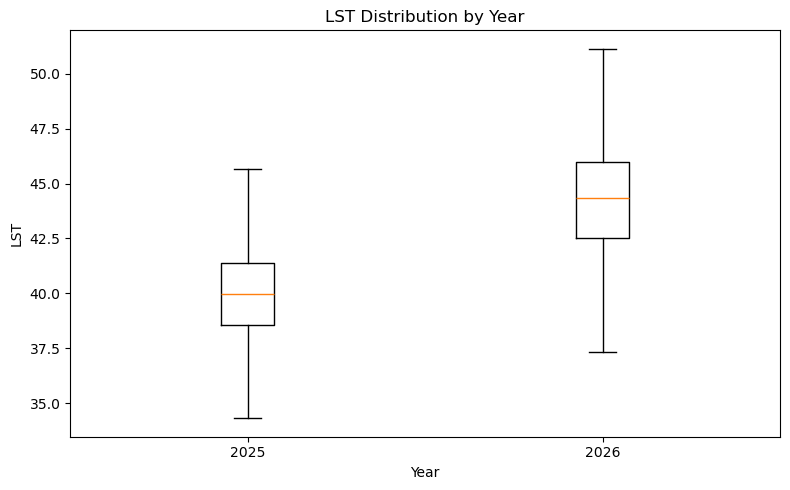

In [11]:
year_plot = (
    df_raw.groupby("year")["LST"]
    .apply(lambda s: s.dropna().values)
)

plt.figure(figsize=(8, 5))
plt.boxplot(
    [year_plot.loc[y] for y in sorted(year_plot.index)],
    labels=[str(y) for y in sorted(year_plot.index)],
    showfliers=False,
)
plt.xlabel("Year")
plt.ylabel("LST")
plt.title("LST Distribution by Year")
plt.tight_layout()
plt.show()

### Spatially Paired Year-over-Year Change

In [12]:
# If the same coordinates occur in both years, calculate location-level change.
# This avoids assuming that observations are paired when they are not.

coords_2025 = df_raw.loc[df_raw["year"] == 2025, ["longitude", "latitude", "LST"]].dropna()
coords_2026 = df_raw.loc[df_raw["year"] == 2026, ["longitude", "latitude", "LST"]].dropna()

paired = coords_2025.merge(
    coords_2026,
    on=["longitude", "latitude"],
    suffixes=("_2025", "_2026"),
)

if len(paired) > 0:
    paired["LST_change"] = paired["LST_2026"] - paired["LST_2025"]
    print(f"Matched spatial locations: {len(paired):,}")
    print(f"Mean location-level change: {paired['LST_change'].mean():.3f}")
    print(f"Median location-level change: {paired['LST_change'].median():.3f}")
    print(f"Locations with higher LST in 2026: {(paired['LST_change'] > 0).mean()*100:.1f}%")
else:
    print("No matching longitude/latitude pairs were found; use the distribution-level comparison above.")

Matched spatial locations: 59,631
Mean location-level change: 4.175
Median location-level change: 3.941
Locations with higher LST in 2026: 99.3%


## 7. LST by Land Use / Land Cover (LULC)

In [13]:
lulc_summary = (
    df_raw.groupby("LULC")["LST"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(3)
)

lulc_summary

,count,mean,median,std,min,max
LULC,,,,,,
60,2596,43.835,43.734,3.250,33.590,54.971
30,16876,43.146,43.060,3.025,32.713,53.479
40,30000,42.699,42.697,3.541,29.712,55.593
50,30000,42.618,42.444,2.609,33.612,52.886
20,7548,42.433,42.764,3.086,32.368,53.625
10,30000,40.268,40.123,2.733,29.712,51.528
80,2202,37.796,37.349,4.296,28.244,56.393
90,40,36.757,35.425,4.638,31.035,47.647


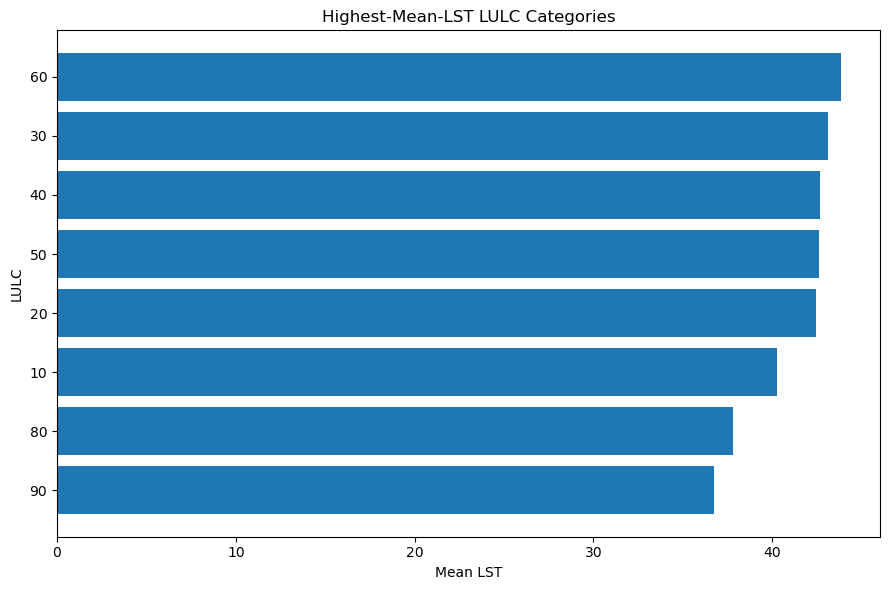

In [14]:
top_lulc = lulc_summary.head(10).sort_values("mean")

plt.figure(figsize=(9, 6))
plt.barh(top_lulc.index.astype(str), top_lulc["mean"])
plt.xlabel("Mean LST")
plt.ylabel("LULC")
plt.title("Highest-Mean-LST LULC Categories")
plt.tight_layout()
plt.show()

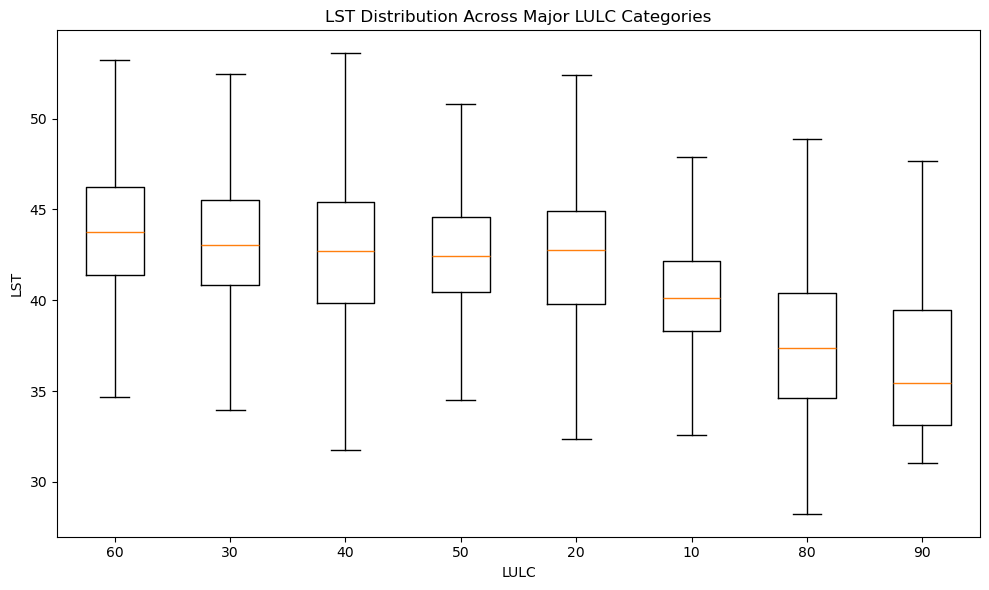

In [15]:
lulc_plot_data = [
    df_raw.loc[df_raw["LULC"] == cls, "LST"].dropna().values
    for cls in lulc_summary.head(8).index
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    lulc_plot_data,
    labels=[str(x) for x in lulc_summary.head(8).index],
    showfliers=False,
)
plt.xlabel("LULC")
plt.ylabel("LST")
plt.title("LST Distribution Across Major LULC Categories")
plt.tight_layout()
plt.show()

## 8. Numeric Relationship Analysis

In [16]:
numeric_df = df_raw.select_dtypes(include=np.number).copy()

corr = numeric_df.corr(numeric_only=True)["LST"].drop("LST").sort_values()

relationship_table = pd.concat(
    [
        corr.head(10).rename("correlation"),
        corr.tail(10).rename("correlation"),
    ]
).to_frame()

relationship_table = relationship_table[~relationship_table.index.duplicated()]
relationship_table

,correlation
WindSpeed,-0.615160
AOD,-0.600631
AirTemp,-0.554483
TreeDensity,-0.380208
NDVI,-0.377643
Emissivity,-0.377396
WaterDensity,-0.215089
Humidity,-0.172830
CoolingPotential,-0.066075
GreenFraction,-0.055611


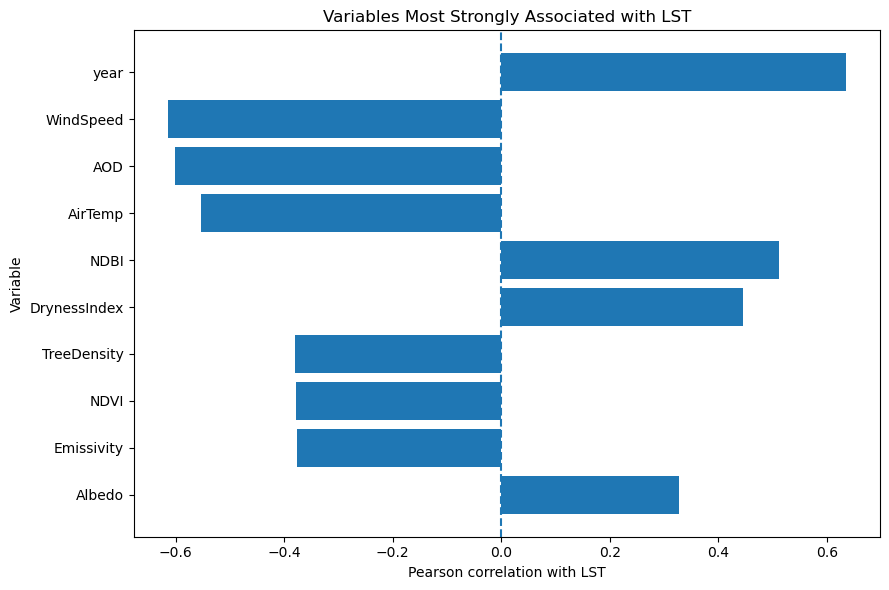

In [17]:
top_corr = corr.abs().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr.index.astype(str), corr.loc[top_corr.index])
plt.axvline(0, linestyle="--")
plt.xlabel("Pearson correlation with LST")
plt.ylabel("Variable")
plt.title("Variables Most Strongly Associated with LST")
plt.tight_layout()
plt.show()

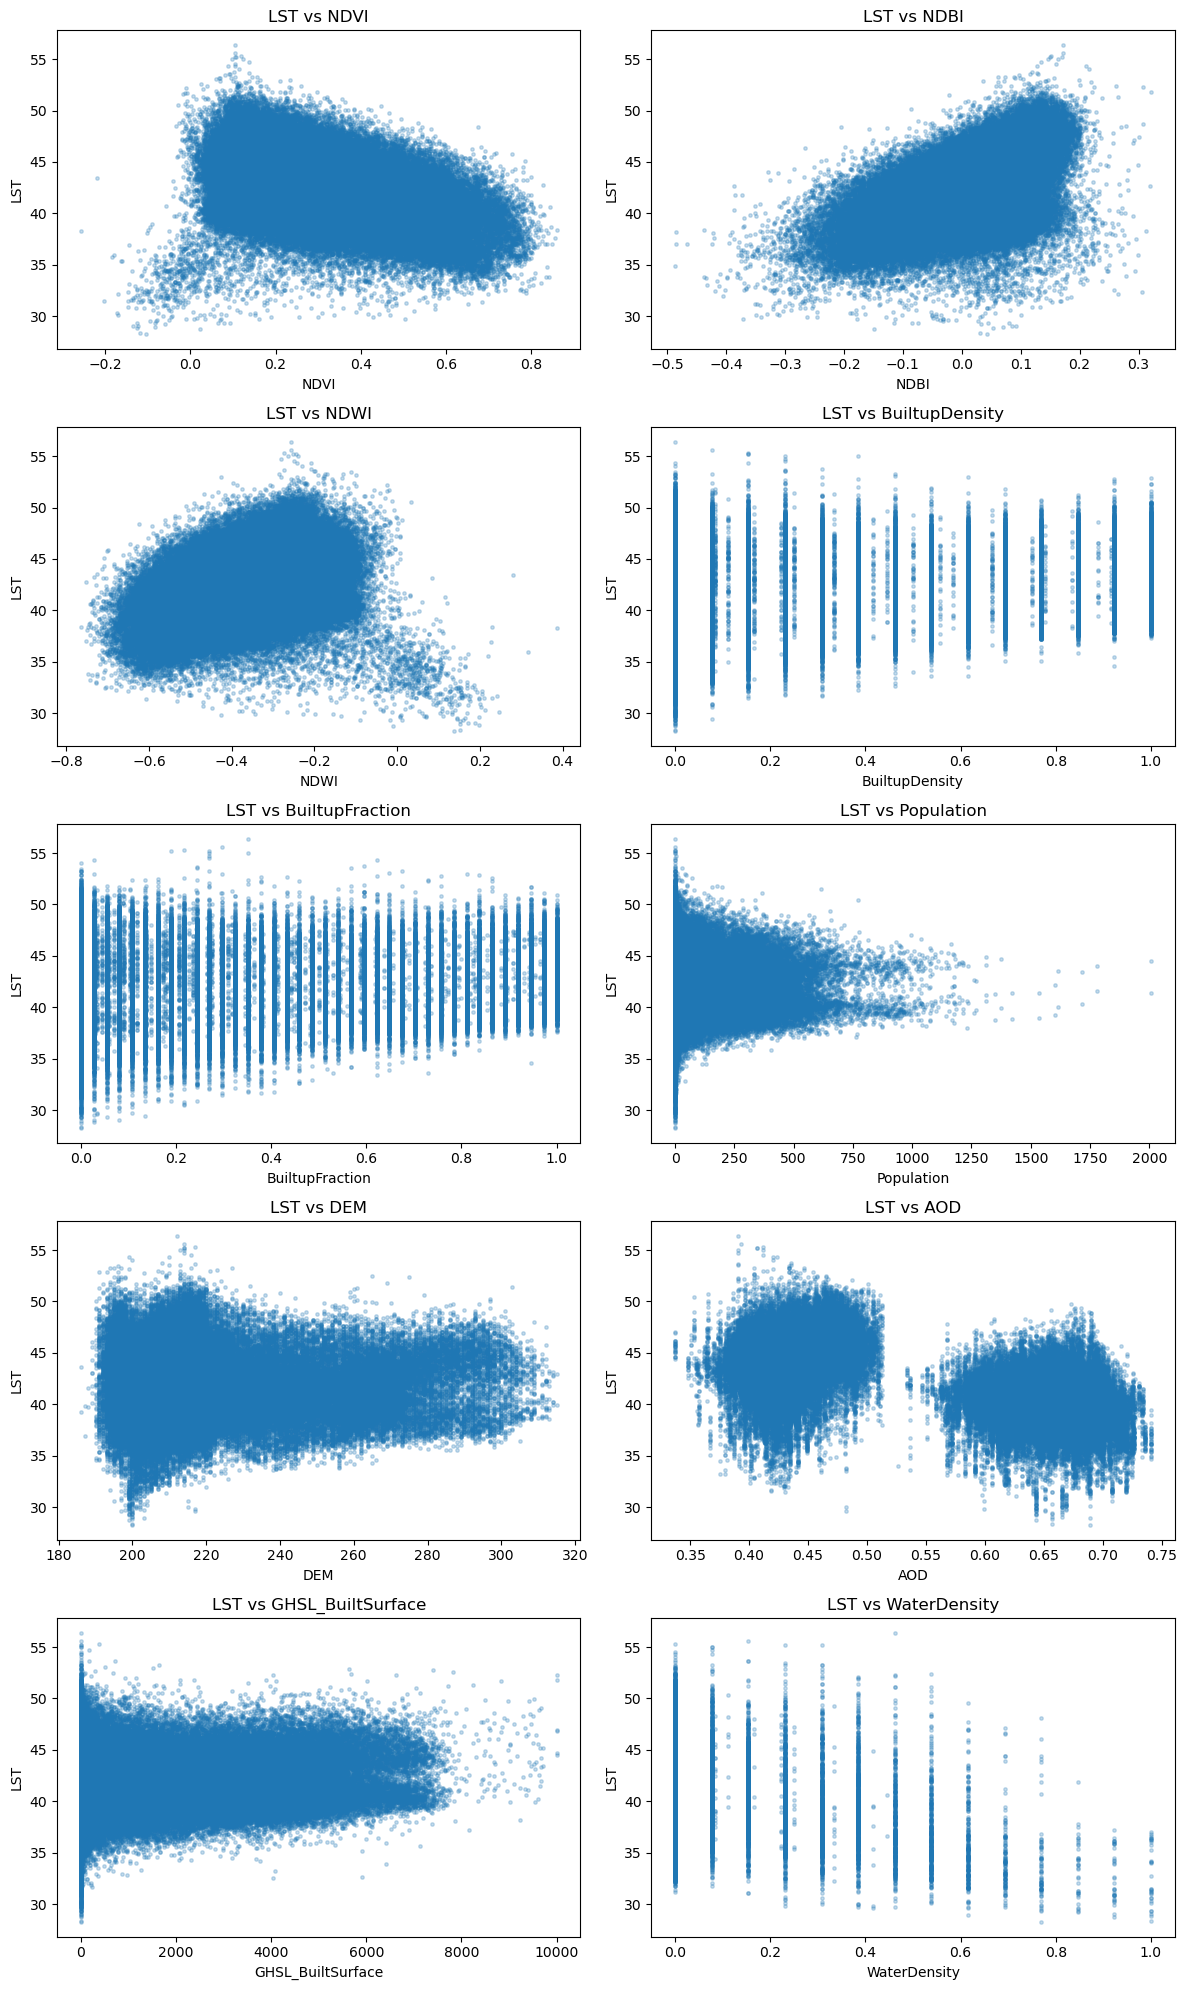

In [18]:
candidate_features = [
    c for c in [
        "NDVI", "EVI", "NDBI", "NDWI",
        "BuiltupDensity", "BuiltupFraction",
        "Population", "DEM", "AOD",
        "GHSL_BuiltSurface", "WaterDensity",
    ]
    if c in df_raw.columns
]

if candidate_features:
    n = len(candidate_features)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, feature in zip(axes, candidate_features):
        subset = df_raw[[feature, "LST"]].dropna()
        ax.scatter(subset[feature], subset["LST"], s=6, alpha=0.25)
        ax.set_xlabel(feature)
        ax.set_ylabel("LST")
        ax.set_title(f"LST vs {feature}")

    for ax in axes[len(candidate_features):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("None of the predefined environmental / built-environment variables are present.")

## 9. Spatial LST Analysis

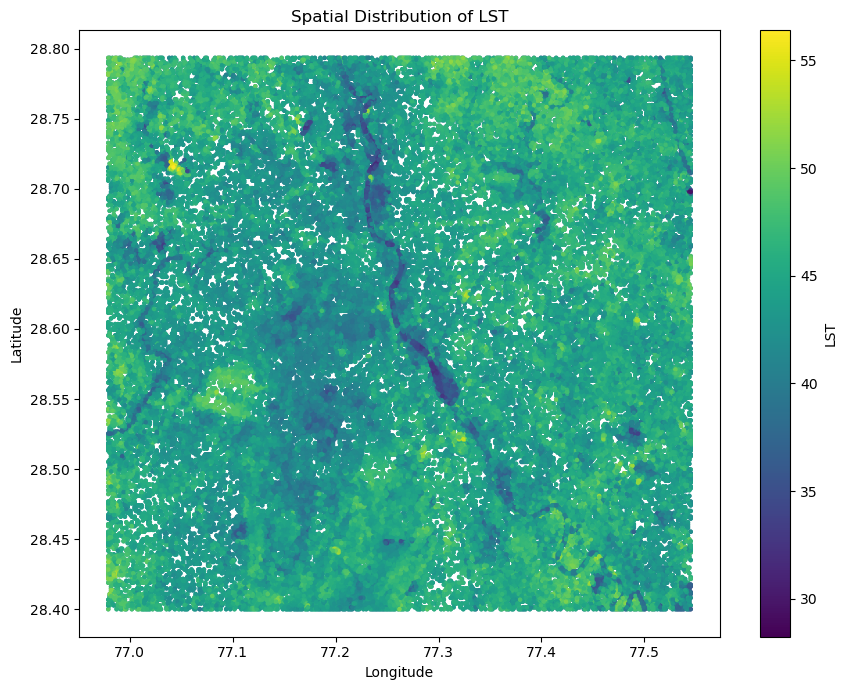

In [19]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df_raw["longitude"],
    df_raw["latitude"],
    c=df_raw["LST"],
    s=5,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of LST")
plt.colorbar(scatter, label="LST")
plt.tight_layout()
plt.show()

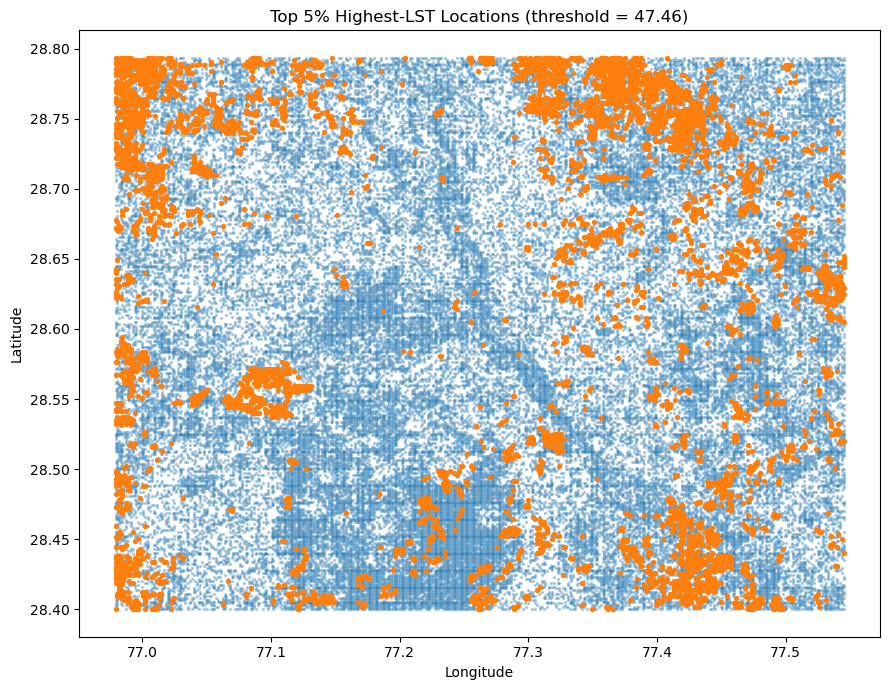

High-LST threshold (95th percentile): 47.455
High-LST observations: 5,970 (5.0%)


In [20]:
high_lst_threshold = df_raw["LST"].quantile(0.95)
high_lst = df_raw[df_raw["LST"] >= high_lst_threshold]

plt.figure(figsize=(9, 7))
plt.scatter(
    df_raw["longitude"],
    df_raw["latitude"],
    s=2,
    alpha=0.15,
)
plt.scatter(
    high_lst["longitude"],
    high_lst["latitude"],
    s=8,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Top 5% Highest-LST Locations (threshold = {high_lst_threshold:.2f})")
plt.tight_layout()
plt.show()

print(f"High-LST threshold (95th percentile): {high_lst_threshold:.3f}")
print(f"High-LST observations: {len(high_lst):,} ({len(high_lst)/len(df_raw)*100:.1f}%)")

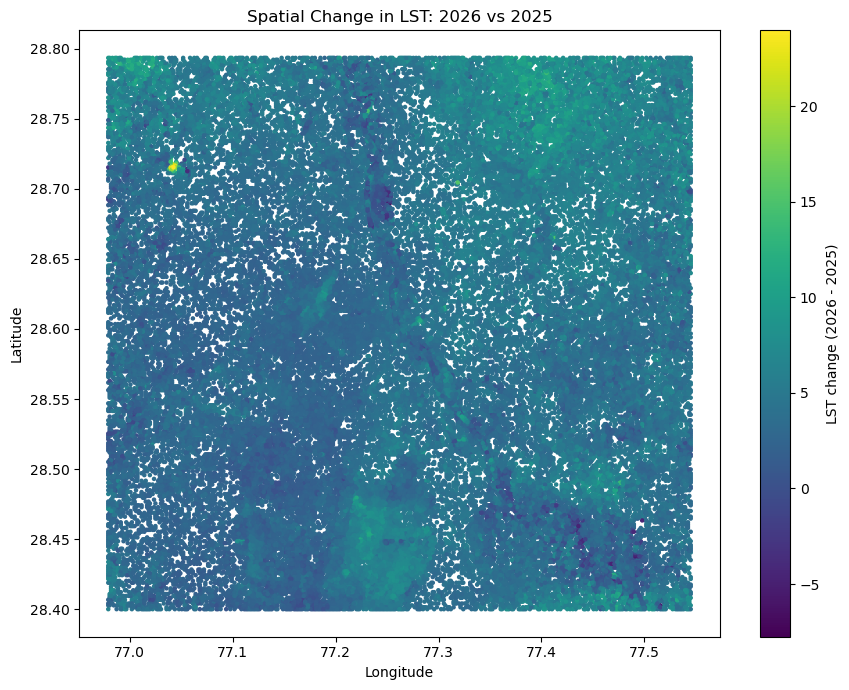

In [21]:
if len(paired) > 0:
    plt.figure(figsize=(9, 7))
    change_scatter = plt.scatter(
        paired["longitude"],
        paired["latitude"],
        c=paired["LST_change"],
        s=5,
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Spatial Change in LST: 2026 vs 2025")
    plt.colorbar(change_scatter, label="LST change (2026 - 2025)")
    plt.tight_layout()
    plt.show()
else:
    print("A paired spatial change map is unavailable because matching coordinates were not found.")

## 10. Prepare the Modelling Dataset

In [22]:
# Work on a separate modelling copy so the raw data remain available for analysis.
df = df_raw.copy()

# Earth Engine export fields are not used as model predictors.
df = df.drop(columns=["system:index", ".geo"], errors="ignore")

# One-hot encode LULC for the ML model.
df = pd.get_dummies(df, columns=["LULC"], dtype=int)

TARGET = "LST"

EXCLUDED_FEATURES = [
    "CoolingPotential",
    "DrynessIndex",
    "Population",
    "DEM",
    "GHSL_BuiltSurface",
    "WaterDensity",
    "Emissivity",
    "BuiltupDensity",
    "AOD",
    "BuiltupFraction",
    "VIIRS",
    "LULC_10",
    "LULC_20",
    "LULC_30",
    "LULC_40",
    "LULC_50",
    "LULC_60",
    "LULC_80",
    "LULC_90",
]

df = df.drop(columns=EXCLUDED_FEATURES, errors="ignore")

feature_exclusions = [
    TARGET,
    "year",
    "longitude",
    "latitude",
    "longi_block",
    "latit_block",
    "block_id",
]

X = df.drop(columns=feature_exclusions, errors="ignore")
y = df[TARGET]

# Keep only model-compatible numeric predictors.
X = X.select_dtypes(include=np.number)

print(f"Prepared modelling data: {len(df):,} rows")
print(f"Number of predictors: {X.shape[1]}")
print(f"Missing target values: {y.isna().sum():,}")

Prepared modelling data: 119,262 rows
Number of predictors: 10
Missing target values: 0


## 11. Create Spatial Blocks

In [23]:
df["longi_block"] = pd.qcut(
    df["longitude"],
    q=N_SPATIAL_BLOCKS,
    labels=False,
    duplicates="drop",
)

df["latit_block"] = pd.qcut(
    df["latitude"],
    q=N_SPATIAL_BLOCKS,
    labels=False,
    duplicates="drop",
)

df["block_id"] = (
    df["latit_block"] * N_SPATIAL_BLOCKS + df["longi_block"]
).astype(int)

print(f"Number of spatial blocks: {df['block_id'].nunique()}")
print(f"Smallest block: {df['block_id'].value_counts().min():,} samples")
print(f"Largest block: {df['block_id'].value_counts().max():,} samples")

Number of spatial blocks: 100
Smallest block: 766 samples
Largest block: 1,678 samples


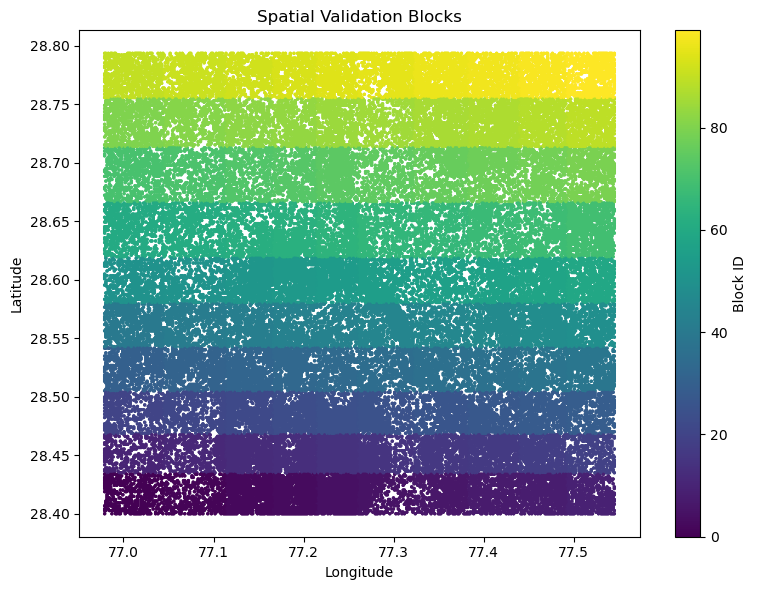

In [24]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["block_id"],
    s=2,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Validation Blocks")
plt.colorbar(scatter, label="Block ID")
plt.tight_layout()
plt.show()

## 12. Spatial Train/Test Split

In [25]:
def spatial_train_test_split(
    X, y, groups, test_size=TEST_SIZE, random_state=RANDOM_STATE
):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    return (
        X.iloc[train_idx],
        X.iloc[test_idx],
        y.iloc[train_idx],
        y.iloc[test_idx],
        groups.iloc[train_idx],
        groups.iloc[test_idx],
    )

groups = df["block_id"]

X_train, X_test, y_train, y_test, groups_train, groups_test = spatial_train_test_split(
    X, y, groups
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print(f"Training blocks:  {groups_train.nunique()}")
print(f"Testing blocks:   {groups_test.nunique()}")

Training samples: 94,184
Testing samples:  25,078
Training blocks:  80
Testing blocks:   20


## 13. Baselines: Mean Predictor and Random Forest

In [26]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

dummy_metrics = {
    "R²": r2_score(y_test, y_pred_dummy),
    "MAE": mean_absolute_error(y_test, y_pred_dummy),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_dummy)),
}

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_metrics = {
    "R²": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
}

baseline_metrics = pd.DataFrame(
    [dummy_metrics, rf_metrics],
    index=["Mean baseline", "Random Forest"],
)

baseline_metrics.round(4)

,R²,MAE,RMSE
Mean baseline,-0.0074,2.8080,3.4907
Random Forest,0.8108,1.1383,1.5130


## 14. XGBoost Hyperparameter Tuning

In [27]:
gkf = GroupKFold(n_splits=5)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    tree_method="hist",
    device=XGB_DEVICE,
)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 7, 9],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=1,
    verbose=1,
)

grid.fit(X_train, y_train, groups=groups_train)

print(f"Best grouped CV R²: {grid.best_score_:.4f}")
print("Best parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best grouped CV R²: 0.8035
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}


## 15. Evaluate the Tuned XGBoost Model

In [28]:
best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

xgb_metrics = {
    "R²": r2_score(y_test, y_pred_xgb),
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
}

metrics = pd.DataFrame(
    [dummy_metrics, rf_metrics, xgb_metrics],
    index=["Mean baseline", "Random Forest", "XGBoost"],
)

metrics.round(4)

,R²,MAE,RMSE
Mean baseline,-0.0074,2.8080,3.4907
Random Forest,0.8108,1.1383,1.5130
XGBoost,0.8188,1.1079,1.4806


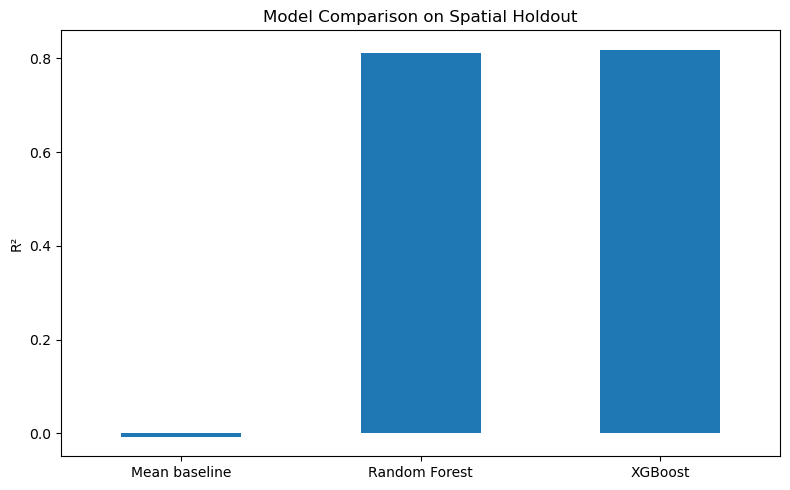

In [29]:
plt.figure(figsize=(8, 5))
metrics["R²"].plot(kind="bar")
plt.ylabel("R²")
plt.title("Model Comparison on Spatial Holdout")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Repeated Spatial Holdout Evaluation

In [30]:
results = []

for seed in range(N_REPEATS):
    X_tr, X_te, y_tr, y_te, _, _ = spatial_train_test_split(
        X, y, groups, random_state=seed
    )

    model = XGBRegressor(
        **grid.best_params_,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        device=XGB_DEVICE,
    )

    model.fit(X_tr, y_tr)
    predictions = model.predict(X_te)

    results.append({
        "seed": seed,
        "test_r2": r2_score(y_te, predictions),
        "mae": mean_absolute_error(y_te, predictions),
        "rmse": np.sqrt(mean_squared_error(y_te, predictions)),
    })

results_df = pd.DataFrame(results)

summary = pd.DataFrame({
    "mean": results_df[["test_r2", "mae", "rmse"]].mean(),
    "std": results_df[["test_r2", "mae", "rmse"]].std(),
})

results_df, summary.round(4)

(   seed   test_r2       mae      rmse
 0     0  0.828689  1.045266  1.369943
 1     1  0.811225  1.069594  1.406868
 2     2  0.775872  1.116417  1.456935
 3     3  0.850766  1.024788  1.352564
 4     4  0.825274  1.081372  1.403356
 5     5  0.781665  1.135157  1.492261
 6     6  0.788997  1.134529  1.495534
 7     7  0.815072  1.069396  1.407847
 8     8  0.829404  1.021495  1.322731
 9     9  0.774477  1.085866  1.429935,
            mean     std
 test_r2  0.8081  0.0264
 mae      1.0784  0.0412
 rmse     1.4138  0.0569)

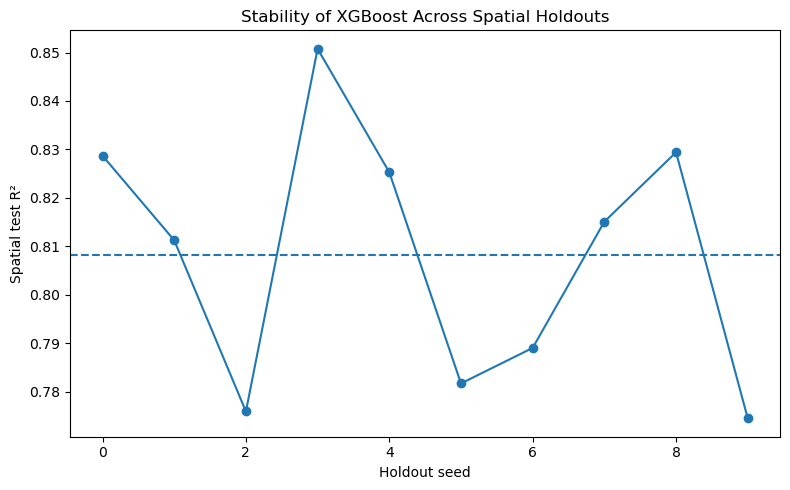

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["seed"], results_df["test_r2"], marker="o")
plt.axhline(results_df["test_r2"].mean(), linestyle="--")
plt.xlabel("Holdout seed")
plt.ylabel("Spatial test R²")
plt.title("Stability of XGBoost Across Spatial Holdouts")
plt.tight_layout()
plt.show()

## 17. Train the Final Model

In [32]:
final_model = XGBRegressor(
    **grid.best_params_,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    tree_method="hist",
    device=XGB_DEVICE,
)

final_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

## 18. Feature Importance

In [33]:
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": final_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,WindSpeed,0.490116
1,NDBI,0.181313
2,AirTemp,0.107384
3,TreeDensity,0.052678
4,Albedo,0.050856
5,NDVI,0.032498
6,Humidity,0.031950
7,DistanceToWater,0.021517
8,NDWI,0.016676
9,GreenFraction,0.015012


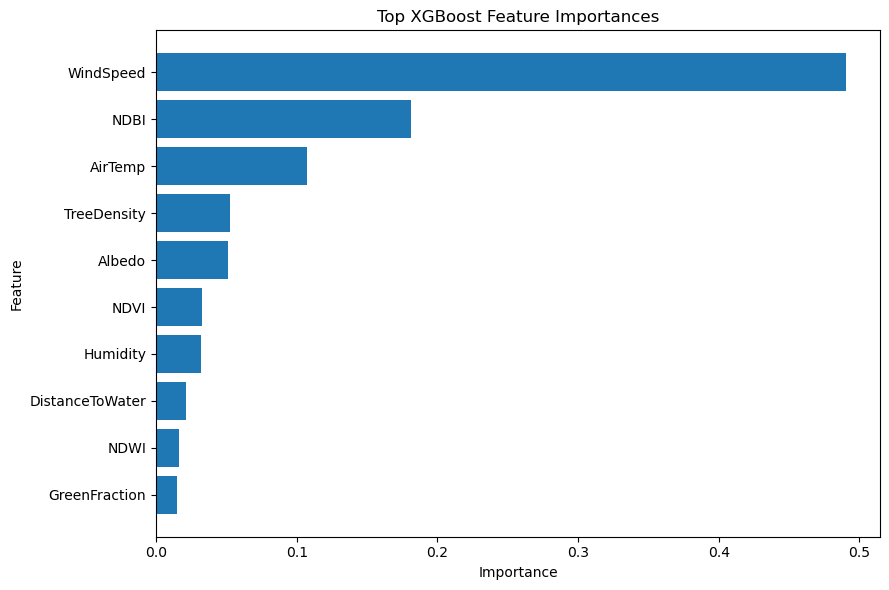

In [34]:
top_n = min(15, len(feature_importance))

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance.head(top_n)["Feature"][::-1],
    feature_importance.head(top_n)["Importance"][::-1],
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## 19. SHAP Model Interpretation

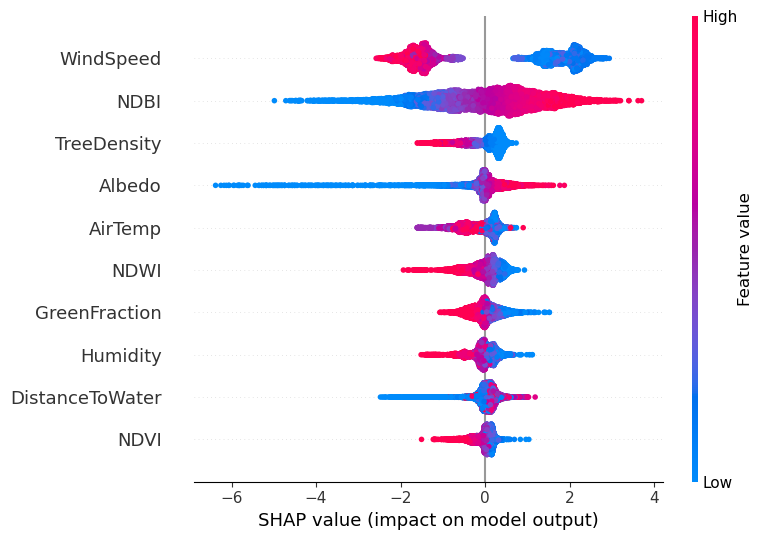

In [35]:
import shap

X_shap = X.sample(
    min(SHAP_SAMPLE_SIZE, len(X)),
    random_state=RANDOM_STATE,
)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
)

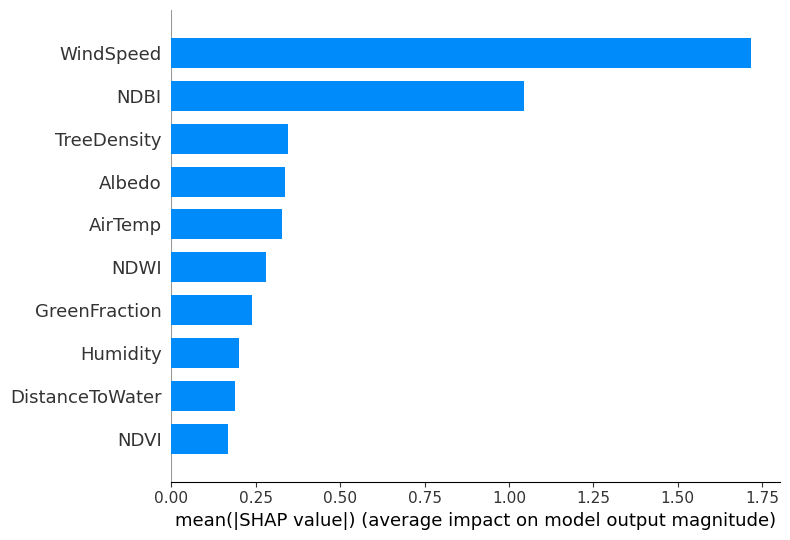

In [36]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
)

## 20. Prediction & Residual Diagnostics

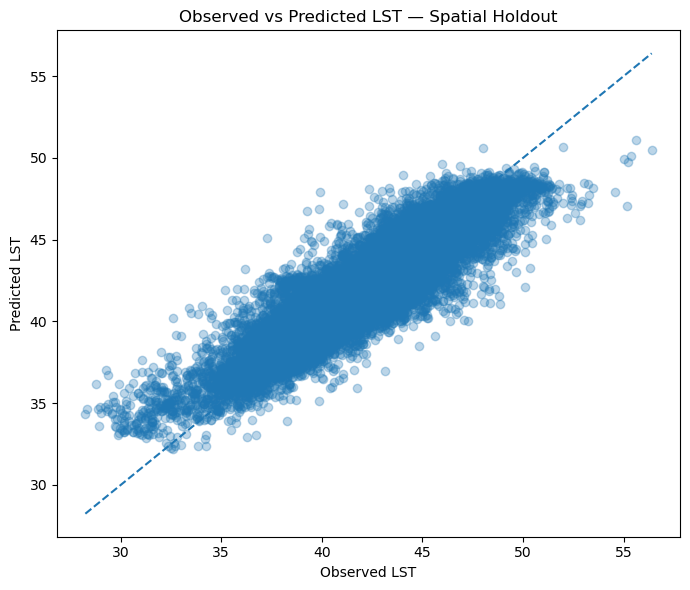

In [37]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
)
plt.xlabel("Observed LST")
plt.ylabel("Predicted LST")
plt.title("Observed vs Predicted LST — Spatial Holdout")
plt.tight_layout()
plt.show()

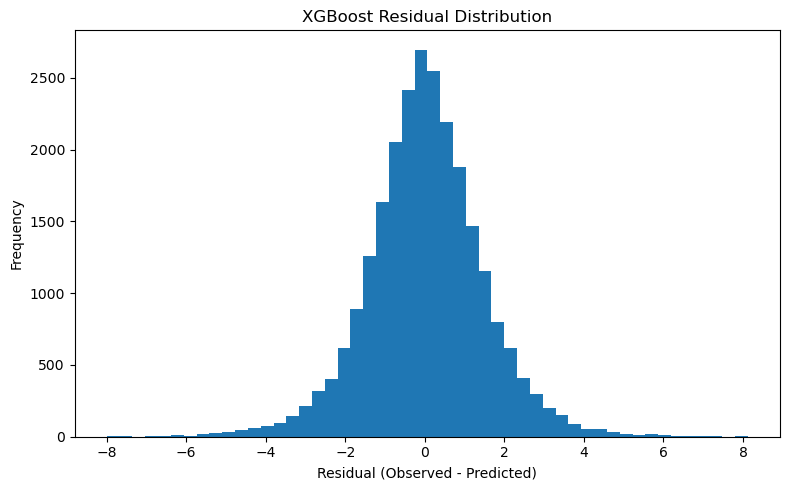

Mean residual:   0.0158
Std. residual:    1.4806
Median residual:  0.0042


In [38]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Observed - Predicted)")
plt.ylabel("Frequency")
plt.title("XGBoost Residual Distribution")
plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():.4f}")
print(f"Std. residual:    {residuals.std():.4f}")
print(f"Median residual:  {residuals.median():.4f}")

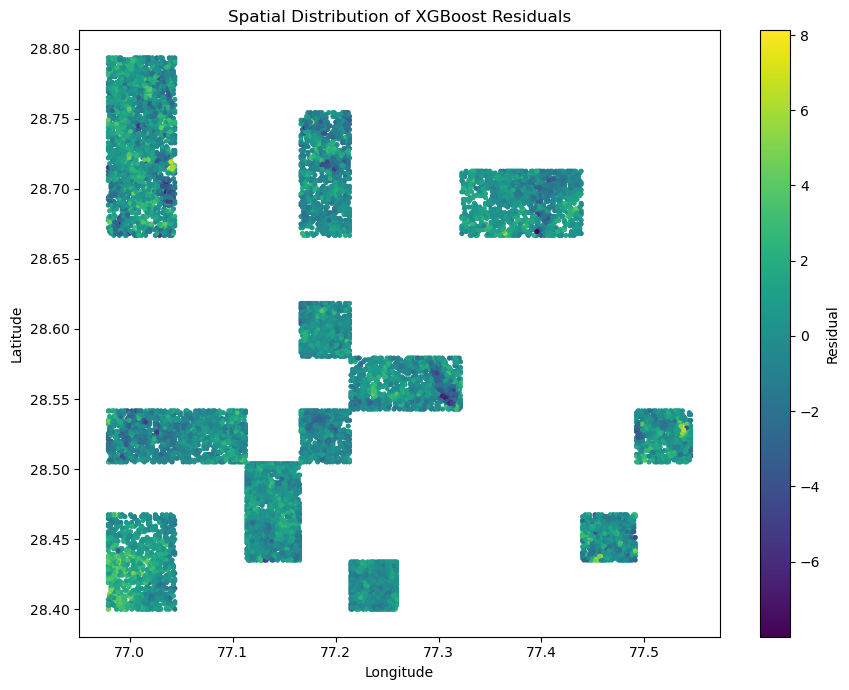

In [39]:
# Map prediction errors back to the held-out locations.
test_diagnostics = df.loc[X_test.index, ["longitude", "latitude"]].copy()
test_diagnostics["observed_LST"] = y_test
test_diagnostics["predicted_LST"] = y_pred_xgb
test_diagnostics["residual"] = residuals.values

plt.figure(figsize=(9, 7))
res_scatter = plt.scatter(
    test_diagnostics["longitude"],
    test_diagnostics["latitude"],
    c=test_diagnostics["residual"],
    s=6,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of XGBoost Residuals")
plt.colorbar(res_scatter, label="Residual")
plt.tight_layout()
plt.show()

## 21. Analyst-Oriented Results Summary

In [40]:
summary_rows = {
    "Observations": len(df_raw),
    "Predictors used by model": X.shape[1],
    "Mean LST": df_raw["LST"].mean(),
    "Median LST": df_raw["LST"].median(),
    "95th percentile LST": df_raw["LST"].quantile(0.95),
    "Spatial test R² (XGBoost)": xgb_metrics["R²"],
    "Spatial test MAE (XGBoost)": xgb_metrics["MAE"],
    "Spatial test RMSE (XGBoost)": xgb_metrics["RMSE"],
    "Repeated spatial R² mean": summary.loc["test_r2", "mean"],
    "Repeated spatial R² std": summary.loc["test_r2", "std"],
}

results_summary = pd.Series(summary_rows).to_frame("value")
results_summary

,value
Observations,119262.000000
Predictors used by model,10.000000
Mean LST,42.045874
Median LST,41.866649
95th percentile LST,47.455112
Spatial test R² (XGBoost),0.818765
Spatial test MAE (XGBoost),1.107905
Spatial test RMSE (XGBoost),1.480609
Repeated spatial R² mean,0.808144
Repeated spatial R² std,0.026425


In [41]:
# Automatically surface the strongest observed relationships without inventing
# domain interpretations that are not supported by the data.

strongest_positive = corr.sort_values(ascending=False).head(5)
strongest_negative = corr.sort_values(ascending=True).head(5)

print("Strongest positive Pearson relationships with LST:")
display(strongest_positive.to_frame("correlation").round(3))

print("Strongest negative Pearson relationships with LST:")
display(strongest_negative.to_frame("correlation").round(3))

print("Warmest LULC categories by mean LST:")
display(lulc_summary.head(5)[["count", "mean"]])

Strongest positive Pearson relationships with LST:


,correlation
year,0.635
NDBI,0.513
DrynessIndex,0.446
Albedo,0.328
NDWI,0.284


Strongest negative Pearson relationships with LST:


,correlation
WindSpeed,-0.615
AOD,-0.601
AirTemp,-0.554
TreeDensity,-0.380
NDVI,-0.378


Warmest LULC categories by mean LST:


,count,mean
LULC,,
60,2596,43.835
30,16876,43.146
40,30000,42.699
50,30000,42.618
20,7548,42.433


## 22. Key Takeaways to Report

Use the generated tables and plots above to write the final project findings. A strong analyst-style summary should report:

1. **Data scale and quality** — number of observations, variables, missingness and outlier checks.
2. **Year-over-year change** — whether average/median LST changed between 2025 and 2026, and whether matched locations show consistent warming/cooling when coordinate pairs exist.
3. **Land-use differences** — which observed LULC categories have the highest and lowest mean LST.
4. **Environmental relationships** — the strongest correlations and the direction of those relationships.
5. **Spatial pattern** — where high-LST observations and year-over-year changes are concentrated.
6. **Predictive performance** — spatial holdout R², MAE and RMSE, plus repeated-holdout stability.
7. **Drivers and errors** — top XGBoost/SHAP features and where residuals are concentrated.

> Do not convert correlation into causation. Treat feature importance and SHAP as evidence of model contribution/association, not proof that a variable independently causes higher LST.

## 22. Preventive & Improvement Measures

The analysis can be extended from **describing and predicting heat patterns** to a simple **decision-support framework**.

The objective is not to claim that a statistical association proves causation. Instead, the results are translated into **evidence-based intervention priorities**:

- Identify areas with unusually high LST.
- Identify areas where LST increased between 2025 and 2026 when spatially matched observations are available.
- Examine which observed environmental / built-environment factors are associated with LST.
- Use those signals to suggest targeted improvement measures.
- Separate **observed evidence** from **recommended action**.

This creates a final chain:

**Data → EDA → Spatial patterns → Drivers/associations → Heat priority → Suggested interventions**

In [42]:
# Build a compact evidence table from the actual dataset.
# Recommendations are generated from observed relationships only;
# they are not presented as causal claims.

recommendation_rows = []

# Vegetation-related variables
vegetation_candidates = [
    c for c in ["NDVI", "EVI"] if c in corr.index
]
if vegetation_candidates:
    veg_feature = min(
        vegetation_candidates,
        key=lambda c: corr.loc[c]
    )
    veg_corr = corr.loc[veg_feature]
    if veg_corr < 0:
        recommendation_rows.append({
            "Evidence": f"{veg_feature} is negatively associated with LST (r={veg_corr:.3f})",
            "Potential implication": "Higher vegetation values tend to occur with lower LST",
            "Suggested measure": "Prioritize preservation/restoration of vegetation and tree-canopy measures in high-LST areas",
            "Priority basis": "High-LST + low vegetation"
        })

# Built-up variables
built_candidates = [
    c for c in [
        "NDBI", "BuiltupDensity", "BuiltupFraction",
        "GHSL_BuiltSurface"
    ] if c in corr.index
]
if built_candidates:
    built_feature = max(
        built_candidates,
        key=lambda c: corr.loc[c]
    )
    built_corr = corr.loc[built_feature]
    if built_corr > 0:
        recommendation_rows.append({
            "Evidence": f"{built_feature} is positively associated with LST (r={built_corr:.3f})",
            "Potential implication": "Higher built-up intensity tends to occur with higher LST",
            "Suggested measure": "Prioritize cool-roof, reflective-surface, shading and heat-sensitive urban-design measures in highly built-up hotspots",
            "Priority basis": "High-LST + high built-up intensity"
        })

# Water-related variable
water_candidates = [c for c in ["NDWI", "WaterDensity"] if c in corr.index]
if water_candidates:
    water_feature = min(
        water_candidates,
        key=lambda c: corr.loc[c]
    )
    water_corr = corr.loc[water_feature]
    if water_corr < 0:
        recommendation_rows.append({
            "Evidence": f"{water_feature} is negatively associated with LST (r={water_corr:.3f})",
            "Potential implication": "Higher water-related values tend to occur with lower LST",
            "Suggested measure": "Protect existing water features and consider context-appropriate blue/green infrastructure in persistent hotspots",
            "Priority basis": "High-LST + low water-related signal"
        })

# Spatial hotspot recommendation
recommendation_rows.append({
    "Evidence": f"Observations above the 95th LST percentile are treated as high-LST locations (threshold={high_lst_threshold:.3f})",
    "Potential implication": "Heat is spatially concentrated rather than uniformly distributed",
    "Suggested measure": "Prioritize detailed site assessment and mitigation planning in the identified high-LST locations",
    "Priority basis": "Top 5% LST"
})

recommendations_df = pd.DataFrame(recommendation_rows)

if recommendations_df.empty:
    print("No automatic evidence-to-action rules were triggered by the available variables.")
else:
    display(recommendations_df)

,Evidence,Potential implication,Suggested measure,Priority basis
0,NDVI is negatively associated with LST (r=-0.378),Higher vegetation values tend to occur with lo...,Prioritize preservation/restoration of vegetat...,High-LST + low vegetation
1,NDBI is positively associated with LST (r=0.513),Higher built-up intensity tends to occur with ...,"Prioritize cool-roof, reflective-surface, shad...",High-LST + high built-up intensity
2,WaterDensity is negatively associated with LST...,Higher water-related values tend to occur with...,Protect existing water features and consider c...,High-LST + low water-related signal
3,Observations above the 95th LST percentile are...,Heat is spatially concentrated rather than uni...,Prioritize detailed site assessment and mitiga...,Top 5% LST


### 22.1 Heat Intervention Priority Score

In [43]:
# Create a transparent, relative priority score for spatially matched locations.
# This is a screening tool, not a formal epidemiological heat-risk index.

if len(paired) > 0:
    priority = paired.copy()

    # Heat level: higher current LST gets a higher percentile score.
    priority["heat_score"] = priority["LST_2026"].rank(pct=True)

    # Change score: larger positive year-over-year changes get higher scores.
    priority["change_score"] = priority["LST_change"].rank(pct=True)

    # Combine the two signals equally.
    priority["intervention_score"] = (
        0.5 * priority["heat_score"] +
        0.5 * priority["change_score"]
    )

    priority["priority"] = pd.cut(
        priority["intervention_score"],
        bins=[-np.inf, 0.50, 0.80, np.inf],
        labels=["Lower", "Medium", "High"],
    )

    priority_summary = (
        priority["priority"]
        .value_counts()
        .reindex(["High", "Medium", "Lower"])
        .fillna(0)
        .astype(int)
        .rename("locations")
        .to_frame()
    )
    priority_summary["percentage"] = (
        priority_summary["locations"] / len(priority) * 100
    ).round(2)

    display(priority_summary)

    print(
        "High-priority locations combine relatively high 2026 LST "
        "with relatively large positive LST change."
    )
else:
    print(
        "The intervention priority score requires matched 2025/2026 "
        "longitude-latitude observations."
    )

,locations,percentage
priority,,
High,8923,14.96
Medium,20781,34.85
Lower,29927,50.19


High-priority locations combine relatively high 2026 LST with relatively large positive LST change.


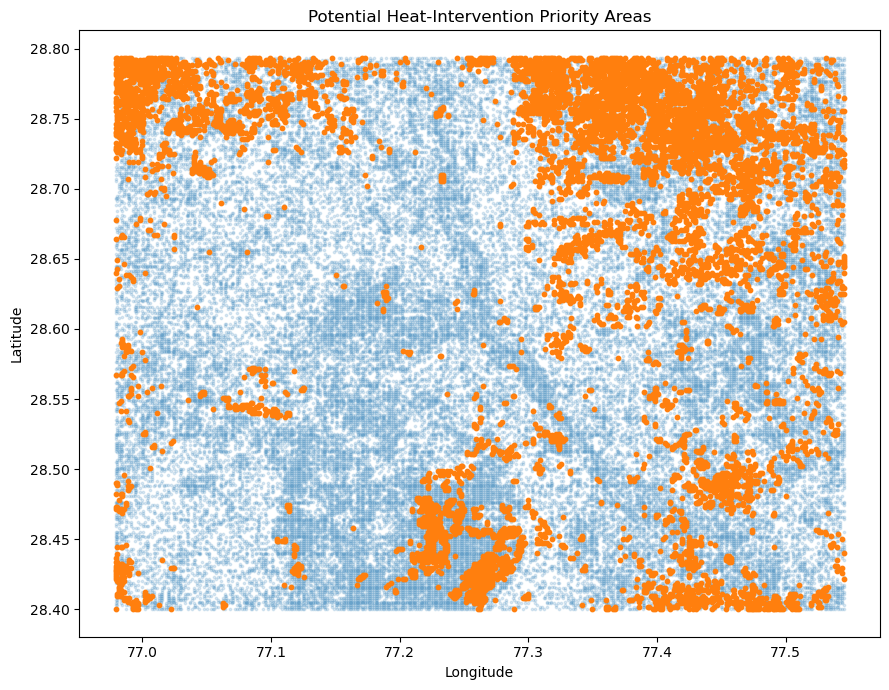

High-priority locations: 8,923


In [44]:
if len(paired) > 0:
    high_priority = priority[priority["priority"] == "High"].copy()

    plt.figure(figsize=(9, 7))
    plt.scatter(
        priority["longitude"],
        priority["latitude"],
        s=3,
        alpha=0.15,
    )
    plt.scatter(
        high_priority["longitude"],
        high_priority["latitude"],
        s=10,
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Potential Heat-Intervention Priority Areas")
    plt.tight_layout()
    plt.show()

    print(f"High-priority locations: {len(high_priority):,}")
else:
    print("Priority map unavailable without matched spatial observations.")

### 22.2 Recommended Intervention Matrix

The following framework links the **observed analytical signal** to a practical response. It should be interpreted as a planning aid rather than a causal prescription.

| Analytical signal | Potential interpretation | Example improvement measure |
|---|---|---|
| Very high LST | Localized surface-heat hotspot | Targeted site assessment and cooling interventions |
| High LST + increasing LST | Potentially worsening heat zone | Prioritize monitoring and mitigation |
| High LST + low vegetation signal | Limited cooling from vegetation | Tree canopy, vegetation restoration and shaded corridors |
| High LST + high built-up signal | Heat associated with built-up intensity | Cool roofs, reflective materials, shading and heat-sensitive design |
| High LST + low water-related signal | Less apparent cooling from water-related features | Preserve water features and consider blue/green infrastructure |
| Large model residuals | Current predictors may not fully explain local heat | Investigate additional variables such as local morphology, materials or microclimate |

The final recommendation should always be tied to the **actual findings generated above**.

### 22.3 Decision-Making Caveat

This framework is intentionally conservative:

- Correlation does not establish causation.
- XGBoost feature importance and SHAP values describe model contribution, not independent causal effects.
- The priority score is a **relative screening score**, not a public-health risk index.
- Recommended interventions should be validated with local planning, infrastructure and field information before implementation.

## 23. Reproducibility & GitHub Notes

- Keep `150m2025Dataset.csv` and `150m2026Dataset.csv` in the same directory as this notebook.
- The raw combined dataset is retained as `df_raw`; the modelling table is created separately as `df`.
- Exploratory analysis is performed **before** the modelling feature exclusions, so potentially useful variables can be analyzed without being used by the final model.
- Coordinates and spatial block IDs are used for spatial validation, not as model predictors.
- `GroupShuffleSplit` keeps complete spatial blocks out of the test set.
- `GroupKFold` is used for grouped hyperparameter tuning.
- XGBoost uses `device="cuda"` by default in the tested environment; set `USE_GPU=False` for CPU execution.
- `GridSearchCV` uses `n_jobs=1` because the XGBoost models are GPU-accelerated.
- SHAP uses a sample of observations to keep visualizations responsive.
- The final XGBoost model is trained on the complete prepared dataset after model selection.